## 1. Install

In [1]:
!pip install -q ultralytics roboflow pyyaml


## 2. Imports

In [2]:
import os, glob, yaml, shutil
from collections import Counter, defaultdict
from getpass import getpass
import matplotlib.pyplot as plt
from roboflow import Roboflow
from ultralytics import YOLO

## 3. Roboflow login

In [3]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="6GUvtYjBqEY4HVKIF4Zt")
project = rf.workspace("noora-fadel").project("garbage-detection-wbhrb-yn9bg")
version = project.version(1)
dataset = version.download("yolo26")




loading Roboflow workspace...
loading Roboflow project...


## 4. Download

In [4]:
DATASET_DIR = dataset.location
yaml_path = os.path.join(DATASET_DIR, "data.yaml")
print(DATASET_DIR)

/content/garbage-detection-1


## 5. Check classes

In [12]:
with open(yaml_path, "r") as f:
    data = yaml.safe_load(f)

class_names = data["names"]
print(class_names)

{0: 'cardboard', 1: 'glass', 2: 'metal', 3: 'paper', 4: 'plastic'}


## 6. Dataset counts

In [13]:
for split in ["train", "valid", "test"]:
    print(split, ":", len(glob.glob(f"{DATASET_DIR}/{split}/images/*")))

train : 1398
valid : 0
test : 600


## 7. Object counts

In [14]:
def names_list(names):
    if isinstance(names, dict):
        return [names.get(i, names.get(str(i))) for i in range(len(names))]
    return list(names)

class_list = names_list(class_names)
class_counts = Counter()
images_per_class = defaultdict(set)
total_images = 0

for split in ["train", "valid", "test"]:
    total_images += len(glob.glob(f"{DATASET_DIR}/{split}/images/*"))

    for label_file in glob.glob(f"{DATASET_DIR}/{split}/labels/*.txt"):
        seen = set()

        for line in open(label_file):
            parts = line.split()
            if not parts:
                continue
            cid = int(parts[0])
            class_counts[cid] += 1
            seen.add(cid)

        for cid in seen:
            images_per_class[cid].add(label_file)

total_objects = sum(class_counts.values())

print("Total images:", total_images)
print("Total objects:", total_objects)
print("Average objects/image:", round(total_objects / total_images, 2))

for i, name in enumerate(class_list):
    print(f"{name}: {class_counts[i]} objects | {len(images_per_class[i])} images")


Total images: 1998
Total objects: 2733
Average objects/image: 1.37
cardboard: 594 objects | 402 images
glass: 404 objects | 400 images
metal: 537 objects | 409 images
paper: 414 objects | 400 images
plastic: 784 objects | 519 images


## 8. Class chart

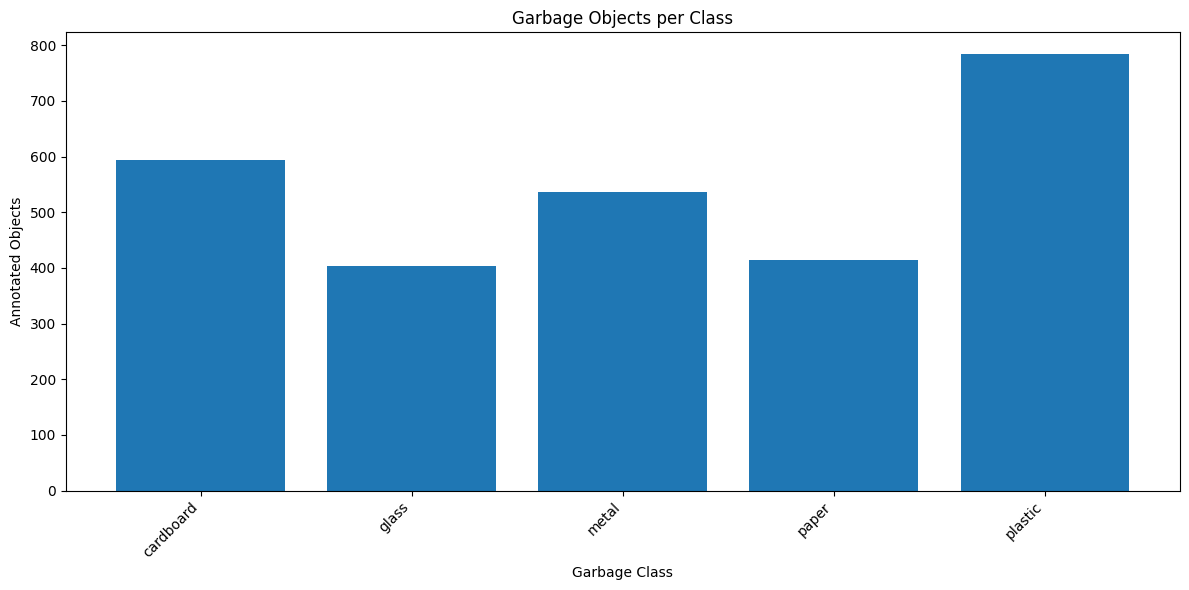

In [15]:
counts = [class_counts[i] for i in range(len(class_list))]

plt.figure(figsize=(12, 6))
plt.bar(class_list, counts)
plt.xlabel("Garbage Class")
plt.ylabel("Annotated Objects")
plt.title("Garbage Objects per Class")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 9. Baseline


image 1/1 /content/garbage-detection-1/test/images/glass469_jpg.rf.cd5e590d9ade4e7243897f2da3215e9f.jpg: 480x640 1 bottle, 10.6ms
Speed: 2.3ms preprocess, 10.6ms inference, 0.6ms postprocess per image at shape (1, 3, 480, 640)


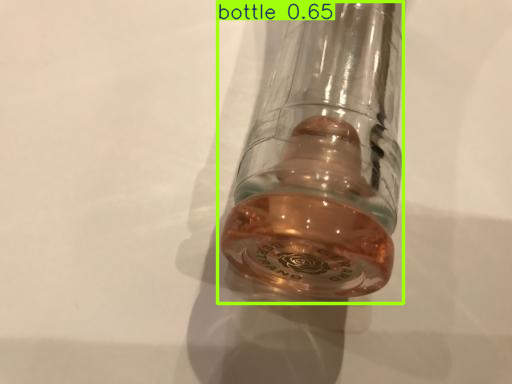

In [16]:
model = YOLO("yolo26n.pt")

test_images = glob.glob(f"{DATASET_DIR}/test/images/*")
if not test_images:
    raise ValueError("No test images found.")

baseline = model(test_images[0])
baseline[0].show()


## 10. Train with early stopping

In [22]:
shutil.rmtree("/content/garbage-detection-1/data.yaml", ignore_errors=True)
yaml_path = "/content/garbage-detection-1/data.yaml"
model = YOLO("yolo26n.pt")

model.train(
    data=yaml_path,
    epochs=20,
    imgsz=640,
    batch=8,
    patience=15,
    project="garbage-detection-wbhrb-yn9bg",
    name="v1"
)

Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/garbage-detection-1/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=v1-26, nbs=64, nms=False

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7c61a6213d90>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

## 11. Load best model

In [30]:
best_path = "/content/runs/detect/garbage-detection-wbhrb-yn9bg/v1-26/weights/best.pt"
v1_model = YOLO(best_path)
print(v1_model.names)

{0: 'cardboard', 1: 'glass', 2: 'metal', 3: 'paper', 4: 'plastic'}


## 12. Evaluate

In [31]:
metrics = v1_model.val(data=yaml_path, split="test")

print("Precision:", round(metrics.box.mp, 4))
print("Recall:", round(metrics.box.mr, 4))
print("mAP50:", round(metrics.box.map50, 4))
print("mAP50-95:", round(metrics.box.map, 4))


Ultralytics 8.4.126 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO26n summary (fused): 122 layers, 2,375,811 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 425.2±197.7 MB/s, size: 11.7 KB)
val: Scanning /content/garbage-detection-1/test/labels... 600 images, 0 backgrounds, 199 corrupt: 100% ━━━━━━━━━━━━ 600/600 2.3Kit/s 0.3s
val: /content/garbage-detection-1/test/images/cardboard281_jpg.rf.4c91a9a3c845f8f32ae6378f1ebe41bb.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/garbage-detection-1/test/images/cardboard284_jpg.rf.1b4fc8e5c0a87e663af5dd4c4dbb1f30.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/garbage-detection-1/test/images/cardboard285_jpg.rf.0ba073178aa10890356c7524e93ffda2.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: /content/garbage-detection-1/test/images/cardboard288_jpg.rf.6047aa7477bdc5002ba1abf922ec19

## 13. Per-class mAP50-95

In [32]:
for name, score in zip(v1_model.names.values(), metrics.box.maps):
    print(name, ":", round(float(score), 4))


cardboard : 0.8576
glass : 0.8503
metal : 0.8474
paper : 0.9514
plastic : 0.6016


## 14. Test images


0: 480x640 1 glass, 3.7ms
1: 480x640 1 plastic, 3.7ms
2: 480x640 1 glass, 3.7ms
3: 480x640 1 cardboard, 3.7ms
4: 480x640 1 glass, 3.7ms
5: 480x640 1 glass, 1 plastic, 3.7ms
6: 480x640 1 cardboard, 3.7ms
7: 480x640 1 cardboard, 3.7ms
8: 480x640 1 cardboard, 1 paper, 3.7ms
9: 480x640 1 glass, 3.7ms
Speed: 2.3ms preprocess, 3.7ms inference, 0.3ms postprocess per image at shape (1, 3, 480, 640)


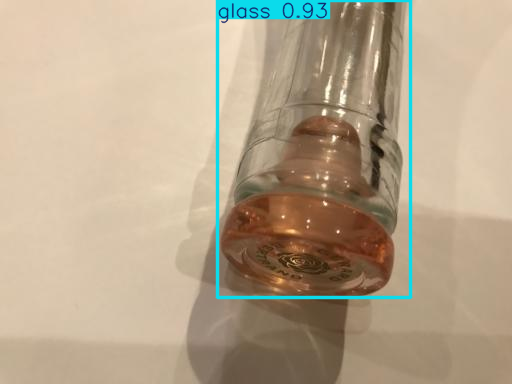

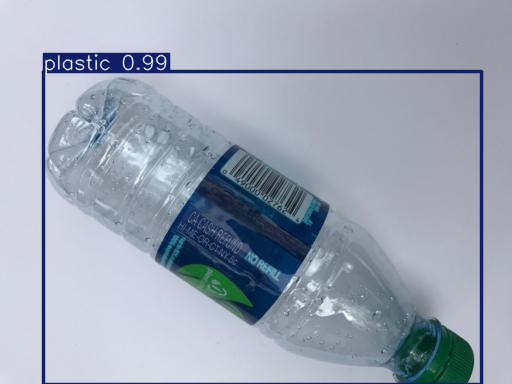

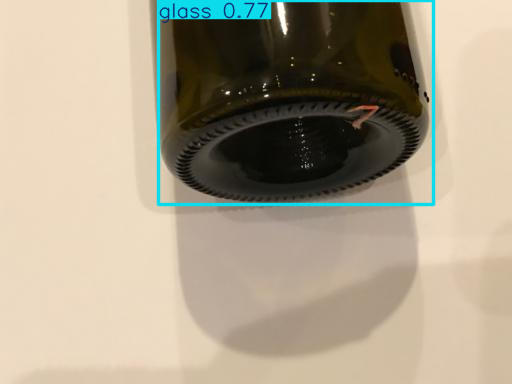

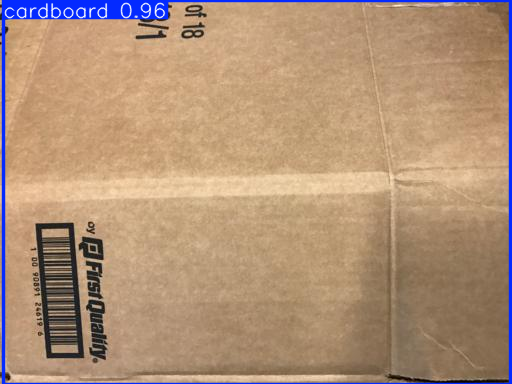

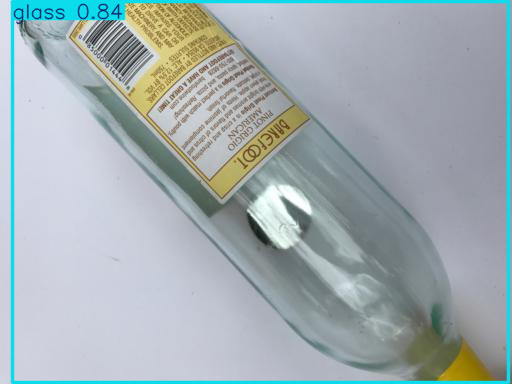

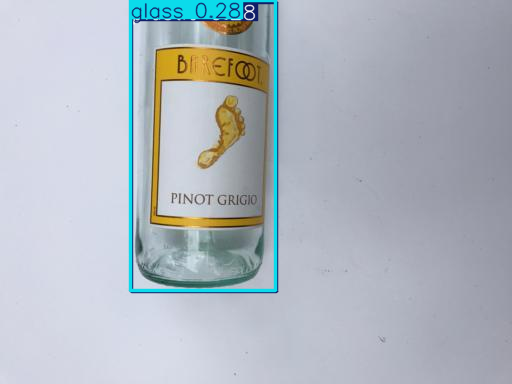

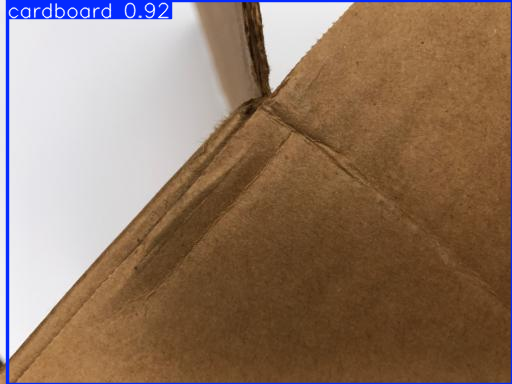

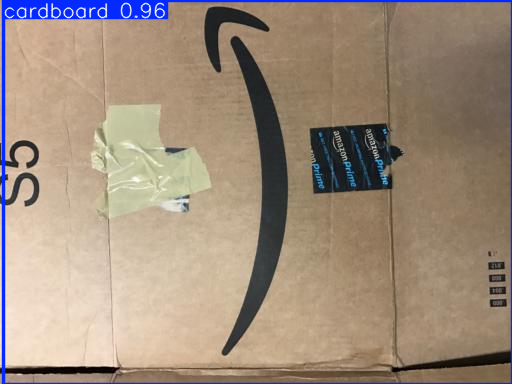

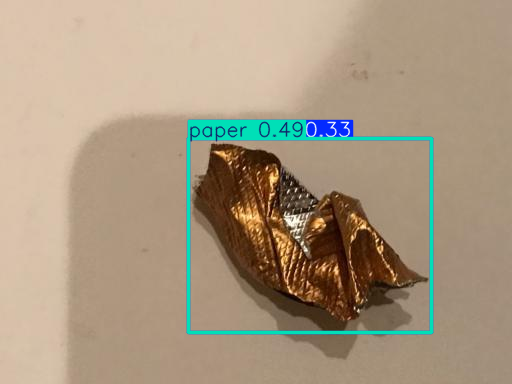

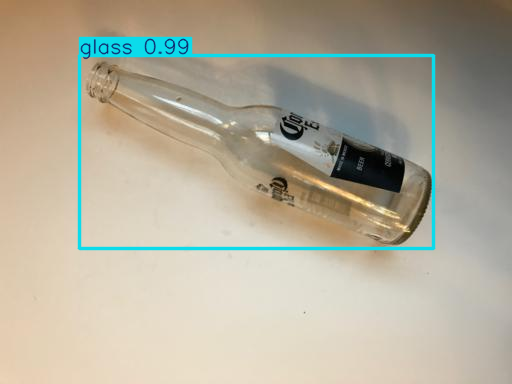

In [33]:
results = v1_model(test_images[:10], conf=0.25)

for result in results:
    result.show()


## 15. Camera setup

In [35]:
from google.colab.output import eval_js
from base64 import b64decode
from IPython.display import Javascript, display

def take_photo(filename="camera_test.jpg"):
    js = Javascript("""
    async function takePhoto() {
      const div = document.createElement('div');
      const video = document.createElement('video');
      const button = document.createElement('button');

      button.textContent = 'Take Photo';
      div.appendChild(video);
      div.appendChild(document.createElement('br'));
      div.appendChild(button);
      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      await new Promise(resolve => button.onclick = resolve);

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg');
    }
    """)

    display(js)
    data = eval_js("takePhoto()")
    binary = b64decode(data.split(",")[1])

    with open(filename, "wb") as f:
        f.write(binary)

    return filename


## 16. Camera detection

<IPython.core.display.Javascript object>


image 1/1 /content/camera_test.jpg: 480x640 (no detections), 12.1ms
Speed: 3.0ms preprocess, 12.1ms inference, 0.5ms postprocess per image at shape (1, 3, 480, 640)


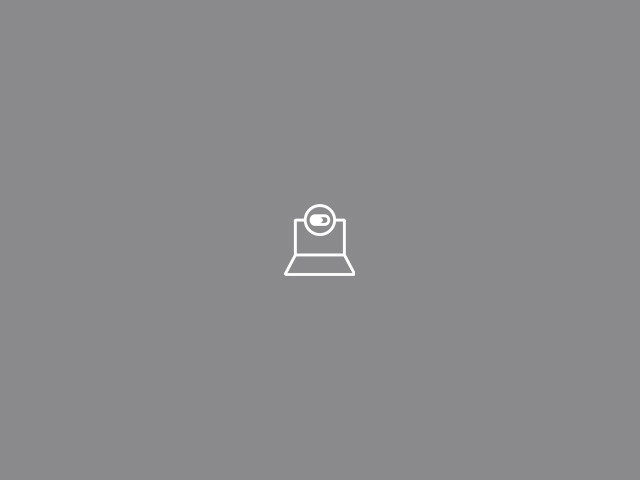

No detections.


In [39]:
camera_image = take_photo()

result = v1_model(camera_image, conf=0.25)
result[0].show()

if len(result[0].boxes) == 0:
    print("No detections.")
else:
    for box in result[0].boxes:
        cid = int(box.cls[0])
        conf = float(box.conf[0])
        print(v1_model.names[cid], f"{conf * 100:.1f}%")